# Environment Setup and Library Imports

Import preliminary required packages

In [1]:
import pretty_midi
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import os
from tqdm import tqdm

/Users/Aresh/Desktop/Final Project/AAI-511-group7/.venv/lib/python3.12/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Feature Extraction

In [ ]:
DATA_DIR = "../Composer_Dataset/NN_midi_files_extended"#"/content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset"
SETS = ['train', 'dev', 'test']
FIXED_SEQUENCE_LENGTH = 5000  # truncate or pad to this many notes

def extract_lstm_features(midi_path, max_length=FIXED_SEQUENCE_LENGTH):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        notes = []
        for inst in midi.instruments:
            if inst.is_drum:
                continue
            notes.extend(inst.notes)
        if not notes:
            return None  # skip empty or drum-only files

        notes.sort(key=lambda n: n.start)
        sequence = []
        prev_start = 0.0
        for note in notes:
            pitch = note.pitch
            velocity = note.velocity
            duration = note.end - note.start
            time_since_last = note.start - prev_start
            sequence.append([pitch, velocity, duration, time_since_last])
            prev_start = note.start

        if len(sequence) >= max_length:
            sequence = sequence[:max_length]
        else:
            reps = int(np.ceil(max_length / len(sequence)))
            sequence = (sequence * reps)[:max_length]

        return np.array(sequence, dtype=np.float32)

    except Exception as e:
        print(f"Failed to process {midi_path}: {e}")
        return None

# Data Containers
X = {'train': [], 'dev': [], 'test': []}
y = {'train': [], 'dev': [], 'test': []}
composer_to_idx = {}

# Dataset Processing
for split in SETS:
    split_path = os.path.join(DATA_DIR, split)
    print(f"Processing {split.upper()} set...")

    for composer_name in os.listdir(split_path):
        composer_path = os.path.join(split_path, composer_name)
        if not os.path.isdir(composer_path):
            continue

        # Assign label
        if composer_name not in composer_to_idx:
            composer_to_idx[composer_name] = len(composer_to_idx)
        label = composer_to_idx[composer_name]

        for fname in tqdm(os.listdir(composer_path), desc=f"{split}/{composer_name}"):
            if not fname.endswith(".mid"):
                continue
            midi_path = os.path.join(composer_path, fname)
            features = extract_lstm_features(midi_path)
            if features is not None:
                X[split].append(features)
                y[split].append(label)

# Convert to numpy arrays
for split in SETS:
    X[split] = np.stack(X[split])
    y[split] = np.array(y[split])

    print(f"{split}: {X[split].shape}, labels: {y[split].shape}")

print("Composer to index mapping:", composer_to_idx)

Saves the extracted LSTM features and labels for each data split (train, dev, test) as `.npy` files using NumPy's `np.save` function. This allows for efficient storage and later loading of preprocessed data, so feature extraction does not need to be repeated each time subsequent code is run. The files are named according to their split and stored in the current working directory.

In [ ]:
# Save as .npy
np.save("X_train_lstm.npy", X['train'])
np.save("y_train_lstm.npy", y['train'])
np.save("X_dev_lstm.npy", X['dev'])
np.save("y_dev_lstm.npy", y['dev'])
np.save("X_test_lstm.npy", X['test'])
np.save("y_test_lstm.npy", y['test'])

# Model Building and Training

## Initial Data Loading

**Summary:**

This section loads the pre-extracted feature and label arrays for the train, development (dev), and test splits from `.npy` files. These files were previously generated during the feature extraction phase and contain the processed MIDI data in a format suitable for model training. By loading these arrays directly, we avoid repeating the time-consuming feature extraction process each time the notebook is run.

**Design Decisions:**

- All feature and label files are stored in the `/notebooks` directory for organizational consistency and easy access.
- After loading, the code prints the shapes of each array to verify that the data has been loaded correctly and that the splits are as expected.
- This cell acts as the bridge between the feature extraction and model building phases, ensuring that the data pipeline is efficient and reproducible.

**Methodology Mapping:**

- This block marks the transition from data preprocessing (feature extraction) to model development.
- It ensures that the data is ready for input into the neural network models, supporting a modular and streamlined workflow.

In [2]:
# Set your local path to the data directory
DATA_PATH = "../notebooks"

# Load .npy data files
X_train = np.load(os.path.join(DATA_PATH, "X_train_lstm.npy"))
y_train = np.load(os.path.join(DATA_PATH, "y_train_lstm.npy"))
X_dev   = np.load(os.path.join(DATA_PATH, "X_dev_lstm.npy"))
y_dev   = np.load(os.path.join(DATA_PATH, "y_dev_lstm.npy"))
X_test  = np.load(os.path.join(DATA_PATH, "X_test_lstm.npy"))
y_test  = np.load(os.path.join(DATA_PATH, "y_test_lstm.npy"))

# Confirm loading shapes
print("Loaded feature and label arrays with shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev:", X_dev.shape, "y_dev:", y_dev.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Loaded feature and label arrays with shapes:
X_train: (369, 5000, 4) y_train: (369,)
X_dev: (35, 5000, 4) y_dev: (35,)
X_test: (35, 5000, 4) y_test: (35,)


## LSTM Model Building

The LSTM model is designed to classify musical scores by composer, leveraging the sequential nature of MIDI feature data. The architecture consists of the following layers:

- **Masking Layer:** Handles variable-length input sequences by ignoring padded values (set to zero), ensuring the model only processes meaningful musical information.
- **LSTM Layer:** Captures long-term dependencies and temporal patterns in the music, making it well-suited for sequential MIDI note data.
- **Dense Layer (ReLU):** Introduces non-linearity and enables the model to learn complex feature representations from the LSTM output.
- **Dropout Layer:** Provides regularization by randomly dropping units during training, which helps prevent overfitting.
- **Output Dense Layer (Softmax):** Produces a probability distribution over all composer classes, supporting

In [3]:
num_classes = len(np.unique(y_train))
input_shape = X_train.shape[1:]  # (5000, 4)

lstm_model = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.LSTM(128, return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()


/Users/Aresh/Desktop/Final Project/AAI-511-group7/.venv/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 5000, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,937 (300.54 KB)

 Trainable params: 76,937 (300.54 KB)

 Non-trainable params: 0 (0.00 B)

## LSTM Model Training

The LSTM model is trained to classify musical scores by composer using the extracted MIDI features. 

- **Training and Validation Split:**  
  The model is trained using a standard split of training and validation data, completed in preceding code. This allows for representative evaluation of the model’s performance during training and helps monitor for overfitting or underfitting.

- **Early Stopping:**  
  To ensure robust generalization and prevent overfitting, early stopping is used. This mechanism monitors the validation loss and halts training when no further improvement is observed, restoring the best weights.

- **Performance Tracking:**  
  Both training and validation loss and accuracy are tracked throughout the process. This provides insight into the model's learning dynamics and helps identify potential issues.

- **Goal:**  
  The approach ensures that the final model achieves optimal performance on unseen data while maintaining generalizability across different composers.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callback for early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Model checkpoint to save the best model
checkpoint = ModelCheckpoint(
    "best_lstm_model.keras", monitor='val_loss', save_best_only=True, save_weights_only=False
)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0
)

### Display training and validation curves

Plotting these curves helps assess the model's learning behavior, diagnose overfitting or underfitting, and determine if early stopping was triggered at an appropriate point. By comparing the trends of training and validation metrics, we can better understand how well the model generalizes to unseen data.

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## LSTM Model Evaluation

The evaluation metrics chosen for the LSTM model are:

- **Accuracy:** Measures the overall proportion of correctly classified samples, providing a general sense of model effectiveness.
- **Precision:** Calculated using the weighted average across all classes, precision reflects how many predicted composers are correct.
- **Recall:** Also weighted across classes, recall indicates how many actual composers are correctly identified.
- **F1-Score:** Combines precision and recall into a single metric, balancing both false positives and false negatives.

Additional evaluation tools include:

- **Classification Report:** Provides per-class precision, recall, and F1-scores, highlighting which composers are most and least accurately classified.
- **Confusion Matrix:** Visualizes the distribution of correct and incorrect predictions across all classes, making it easier to identify specific patterns of misclassification.

Test Accuracy: 0.4286
Test Loss: 1.4371

Detailed Test Metrics:
Accuracy:  0.4286
Precision: 0.3736
Recall:    0.4286
F1-Score:  0.3948

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.50      0.36         4
           1       0.40      0.50      0.44         4
           2       0.00      0.00      0.00         4
           3       0.60      0.75      0.67         4
           4       0.00      0.00      0.00         3
           5       0.40      0.50      0.44         4
           6       0.75      0.75      0.75         4
           7       0.50      0.50      0.50         4
           8       0.33      0.25      0.29         4

    accuracy                           0.43        35
   macro avg       0.36      0.42      0.38        35
weighted avg       0.37      0.43      0.39        35



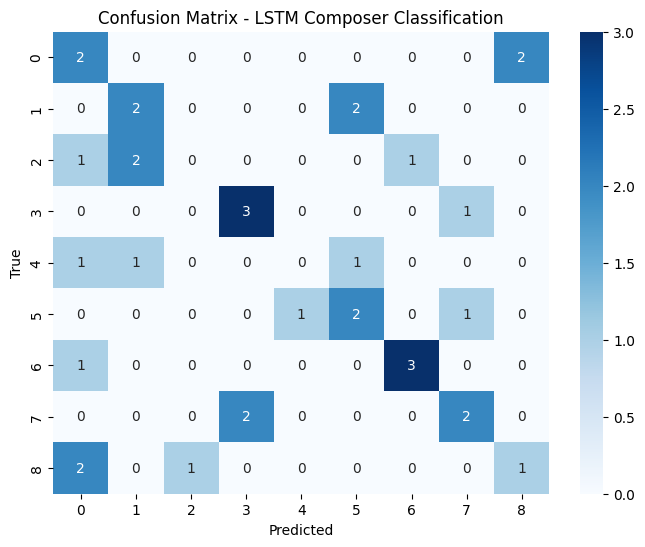

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred_probs = lstm_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nDetailed Test Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LSTM Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## CNN Model Building and Training

**Summary:**

This section constructs a 1D Convolutional Neural Network (CNN) as an alternative architecture for classifying composer sequences. The CNN is designed to process sequential MIDI feature data and extract local temporal patterns.

**Layer Structure:**

- `Conv1D` → `MaxPooling1D` → `Conv1D` → `MaxPooling1D` → `Flatten` → `Dense` → `Dropout` → `Dense (Softmax)`

**Training Approach:**

- The CNN model is compiled and trained using the same methodology as the LSTM model, allowing for direct performance comparison.

**Design Decisions:**

- CNNs are evaluated for their ability to capture local patterns in the extracted music features and their robustness with high-dimensional sequential inputs.
- This architecture is included to compare against the LSTM model as part of experimentation and ablation studies.

**Methodology Mapping:**

- **Model Building/Training:** Implements the methodology's directive to develop both LSTM

In [ ]:
cnn_model = keras.Sequential([
    layers.Conv1D(64, kernel_size=7, activation='relu', input_shape=input_shape),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=7, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Train
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0   # No verbose output for cleaner logs
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4994, 64)       │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2497, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2491, 128)      │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1245, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 159360)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    10,199,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,259,017 (39.14 MB)

 Trainable params: 10,259,017 (39.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 532ms/step - accuracy: 0.1661 - loss: 135.4257 - val_accuracy: 0.1143 - val_loss: 2.1979
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 509ms/step - accuracy: 0.1843 - loss: 2.1907 - val_accuracy: 0.1143 - val_loss: 2.1975
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 512ms/step - accuracy: 0.2166 - loss: 2.1339 - val_accuracy: 0.1143 - val_loss: 2.2012
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 534ms/step - accuracy: 0.2098 - loss: 2.0859 - val_accuracy: 0.2000 - val_loss: 2.2376
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 518ms/step - accuracy: 0.2222 - loss: 2.0250 - val_accuracy: 0.1143 - val_loss: 2.2031
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 468ms/step - accuracy: 0.2121 - loss: 2.0635 - val_accuracy: 0.1429 - val_loss: 2.2095
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 509ms/step - accuracy: 0.2659 - loss: 1.9199 - val_accuracy: 0.2571 - val_loss: 2.3326


## CNN Model Evaluation

**Summary:**

This section evaluates the performance of the CNN model on the test set using standard classification metrics.

**Design Decisions:**

- The evaluation metrics and methodology are kept consistent with those used for the LSTM model, enabling a direct and fair comparison between the two architectures.
- This approach helps determine which model is better suited for composer classification based on the extracted MIDI features.

**Methodology Mapping:**

- **Model Evaluation:** Applies accuracy, precision, recall, F1-score, and classification reports to assess model performance.
- **Model Optimization:** Informs further tuning or selection of the most effective architecture for the task.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (CNN): {test_acc_cnn:.4f}")
print(f"Test Loss (CNN): {test_loss_cnn:.4f}")

# Predictions
y_pred_probs_cnn = cnn_model.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# Metrics
accuracy_cnn = accuracy_score(y_test, y_pred_cnn)
precision_cnn = precision_score(y_test, y_pred_cnn, average='weighted')
recall_cnn = recall_score(y_test, y_pred_cnn, average='weighted')
f1_cnn = f1_score(y_test, y_pred_cnn, average='weighted')

print("\nDetailed Test Metrics (CNN):")
print(f"Accuracy:  {accuracy_cnn:.4f}")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall:    {recall_cnn:.4f}")
print(f"F1-Score:  {f1_cnn:.4f}")

# Classification report
print("\nClassification Report (CNN):")
print(classification_report(y_test, y_pred_cnn))

# Confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2062 - loss: 2.1879 
Test accuracy (CNN): 0.200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step
              precision    recall  f1-score   support

           0       0.15      1.00      0.27         4
           1       0.50      0.25      0.33         4
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         4
           4       0.29      0.67      0.40         3
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         4

    accuracy                           0.20        35
   macro avg       0.10      0.21      0.11        35
weighted avg       0.10      0.20      0.10        35



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model Comparison: LSTM vs CNN

Compare models and respective performance here

# Model Optimization

### LSTM Optimization: Batch Normalization

**Summary:**

This section demonstrates a variant of the LSTM model that incorporates batch normalization. Batch normalization can help stabilize and accelerate training by normalizing the outputs of the LSTM layer, potentially leading to improved convergence and generalization.

**Design Decisions:**

- Batch normalization is added after the LSTM layer to regularize the model and reduce internal covariate shift.
- Dropout is also used for additional regularization.

**Methodology Mapping:**

- **Model Optimization:** This experiment explores architectural enhancements to improve model performance and training efficiency.

In [ ]:
# Add batch normalization
lstm_model_bn = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.LSTM(128, return_sequences=False),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model (use same callbacks as before)
history_bn = lstm_model_bn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0   # No verbose output for cleaner logs
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## CNN Optimization:

optimization attempt here

**Composer_to_idx Dictionary Save/Load**

Summary:

Shows how to pickle and reload the label encoder dictionary.

Design Decisions:

Ensures reproducibility and mapping from numeric class labels back to original composer names.

Methodology Mapping:

Data Pre-processing/Utility (supports all methodology steps requiring label consistency).

In [15]:
import pickle
composer_to_idx = {}
# Save
with open(os.path.join(DATA_PATH, "composer_to_idx.pkl"), "wb") as f:
    pickle.dump(composer_to_idx, f)

# Load
with open(os.path.join(DATA_PATH, "composer_to_idx.pkl"), "rb") as f:
    composer_to_idx = pickle.load(f)
idx_to_composer = {v:k for k, v in composer_to_idx.items()}


**Sugestions if we need**

Top-k accuracy (useful if you want to accept the correct class in top-2 or top-3 predictions)

In [18]:
top_k_acc = tf.keras.metrics.top_k_categorical_accuracy(
    keras.utils.to_categorical(y_test, num_classes),
    lstm_model.predict(X_test), k=3
).numpy().mean()
print(f"Top-3 Accuracy: {top_k_acc:.3f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 408ms/step
Top-3 Accuracy: 0.829


Feature Importance (Optional/Advanced)
You might use SHAP or similar tools for neural nets to see which note features most influence predictions (advanced).

Composer-level Metrics: Show metrics aggregated at the composer level (e.g., which composers are easiest/hardest to classify).

Error Analysis: Highlight and interpret common misclassifications—are certain composer pairs often confused? Why?

Experiment Tracker Table: Keep a markdown table of experiment settings/validation/test results to document LSTM vs. CNN runs.

Tempo/Key Analysis: Compare results on slow vs. fast, major vs. minor works (if you have such features).

Augmentation Studies: Try augmenting MIDI data (pitch/time shift) and study its impact (if time allows).

Notebook Polish: Add markdown explanations and section headers; use markdown cells to explain each experimental block.

Reproducibility: Save all random seeds and versions of key libraries used.

Conclusion Section: Summarize best results, strengths, and limitations; suggest future work (e.g., transformer models, including raw audio).